Nombre: Emilio Rico Hernández
Clase: Práctica de 30 minutos
Ejercicio: Del CSV a una conclusión
Fecha: 2026-09-25

# Práctica: Del CSV a una conclusión

Flujo corto de análisis con `ventas.csv` y `regiones.csv`: carga, indicadores, outliers, dos gráficas y un merge para ver las ventas por región.

> Nota sobre los archivos: en `regiones.csv` la columna con el nombre de la región se llama `region` (en el instructivo aparece como `nombre_region`), así que uso `region` en el código.

## Parte 1. Carga y reconocimiento de los datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

ventas = pd.read_csv("ventas_2.csv")   # el ventas.csv de esta práctica (6000 transacciones)
ventas.head()

,fecha,region_id,vendedor,producto_id,cantidad,nombre_producto,categoria,precio_unitario,total
0,2023-01-01,1,Vendedor_4,7,9,Producto 7,Electrónica,1932.73,17394.57
1,2023-01-01,3,Vendedor_10,5,5,Producto 5,Ropa,1240.04,6200.20
2,2023-01-01,5,Vendedor_6,1,1,Producto 1,Electrónica,1264.57,1264.57
3,2023-01-01,4,Vendedor_9,14,3,Producto 14,Deportes,2949.45,8848.35
4,2023-01-01,2,Vendedor_6,17,4,Producto 17,Ropa,1593.14,6372.56


In [2]:
ventas.shape

(6000, 9)

In [3]:
ventas.columns

Index(['fecha', 'region_id', 'vendedor', 'producto_id', 'cantidad',
       'nombre_producto', 'categoria', 'precio_unitario', 'total'],
      dtype='str')

In [4]:
ventas.dtypes

fecha                  str
region_id            int64
vendedor               str
producto_id          int64
cantidad             int64
nombre_producto        str
categoria              str
precio_unitario    float64
total              float64
dtype: object

In [5]:
# Verificación rápida: nulos y duplicados
print("Nulos por columna:", ventas.isna().sum().sum())
print("Filas duplicadas:", ventas.duplicated().sum())
print("Rango de fechas:", ventas["fecha"].min(), "->", ventas["fecha"].max())

Nulos por columna: 0
Filas duplicadas: 0
Rango de fechas: 2023-01-01 -> 2025-12-31


**Respuestas**

a) **¿Cuántas observaciones contiene el dataset?** 6,000 filas, y no hay nulos ni duplicados, así que los 6,000 registros son utilizables.

b) **¿Cuántas variables contiene?** 9 columnas: `fecha`, `region_id`, `vendedor`, `producto_id`, `cantidad`, `nombre_producto`, `categoria`, `precio_unitario` y `total`.

c) **¿Qué representa una fila?** Una transacción de venta: en cierta fecha, un vendedor vendió cierta cantidad de un producto en una región. El `total` es `cantidad × precio_unitario` (lo verifiqué contra los datos y coincide).

Detalle a tener en cuenta: `region_id` es solo un número; el nombre de la región no viene en este archivo, por eso más adelante hace falta el merge con `regiones.csv`. Además, `fecha` viene como texto y cubre de 2023-01-01 a 2025-12-31 (tres años).

## Parte 2. Indicadores principales

In [6]:
venta_total = ventas["total"].sum()
venta_promedio = ventas["total"].mean()

ventas_producto = ventas.groupby("nombre_producto")["total"].sum().sort_values(ascending=False)
ventas_vendedor = ventas.groupby("vendedor")["total"].sum().sort_values(ascending=False)

producto_top = ventas_producto.idxmax()
vendedor_top = ventas_vendedor.idxmax()

print(f"Venta total acumulada:       ${venta_total:,.2f}")
print(f"Venta promedio por transacción: ${venta_promedio:,.2f}")
print(f"Producto con mayor monto:    {producto_top} (${ventas_producto.max():,.2f})")
print(f"Vendedor con mayor monto:    {vendedor_top} (${ventas_vendedor.max():,.2f})")

Venta total acumulada:       $61,984,064.58
Venta promedio por transacción: $10,330.68
Producto con mayor monto:    Producto 13 ($5,657,119.42)
Vendedor con mayor monto:    Vendedor_1 ($4,654,426.57)


In [7]:
# Los tres primeros de cada ranking, para ver qué tan cerrada está la competencia
print(ventas_producto.head(3).round(2))
print()
print(ventas_vendedor.head(3).round(2))

nombre_producto
Producto 13    5657119.42
Producto 14    5234997.57
Producto 4     5115906.98
Name: total, dtype: float64

vendedor
Vendedor_1     4654426.57
Vendedor_12    4406658.37
Vendedor_6     4304754.07
Name: total, dtype: float64


| Indicador | Resultado |
|---|---|
| Venta total acumulada | $61,984,064.58 |
| Venta promedio por transacción | $10,330.68 |
| Producto con mayores ventas | Producto 13 ($5,657,119.42) |
| Vendedor con mayores ventas | Vendedor_1 ($4,654,426.57) |

Los rankings no están tan separados como parece: Producto 13 le gana a Producto 14 por ~$420 mil (8% más) y Vendedor_1 le saca ~$250 mil (5.6%) a Vendedor_12. Con tres años de datos y el ruido normal de las ventas, no diría que hay un "ganador" contundente en ninguno de los dos casos, más bien un grupo de cabeza parejo.

## Parte 3. Exploración y valores atípicos

In [8]:
ventas[["cantidad", "precio_unitario", "total"]].describe()

,cantidad,precio_unitario,total
count,6000.000000,6000.000000,6000.000000
mean,6.068500,1698.233145,10330.677430
std,3.175398,885.641029,8153.475421
min,1.000000,161.430000,161.530000
25%,3.000000,1004.095000,3285.052500
50%,6.000000,1826.945000,8214.840000
75%,9.000000,2457.115000,15586.277500
max,11.000000,3348.270000,36342.570000


In [9]:
q1 = ventas["total"].quantile(0.25)
q3 = ventas["total"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = ventas[
    (ventas["total"] < limite_inferior) |
    (ventas["total"] > limite_superior)
]

print(f"Q1 = {q1:,.2f} | Q3 = {q3:,.2f} | IQR = {iqr:,.2f}")
print(f"Límites: [{limite_inferior:,.2f}, {limite_superior:,.2f}]")
print("Numero de outliers:", len(outliers))
print(f"Porcentaje del total de filas: {len(outliers) / len(ventas):.1%}")

Q1 = 3,285.05 | Q3 = 15,586.28 | IQR = 12,301.23
Límites: [-15,166.79, 34,038.12]
Numero de outliers: 16
Porcentaje del total de filas: 0.3%


In [10]:
# ¿Qué tienen en común los outliers? Miro los productos y las cantidades
print(outliers["nombre_producto"].value_counts().head(5))
print()
print(outliers["cantidad"].value_counts().sort_index())
print()
print("Total máximo:", ventas["total"].max())

nombre_producto
Producto 13    10
Producto 2      6
Name: count, dtype: int64

cantidad
11    16
Name: count, dtype: int64

Total máximo: 36342.57


**Lectura de la estadística descriptiva.** La media del `total` ($10,331) es mayor que la mediana ($8,215), lo que apunta a una cola larga hacia la derecha: pocas transacciones muy grandes jalan el promedio hacia arriba. `cantidad` va de 1 a 11 unidades y `precio_unitario` de ~$161 a ~$3,348.

**Outliers con el método IQR.** Con Q1 = $3,285, Q3 = $15,586 y un IQR de $12,301, el límite superior queda en $34,038 (el inferior es negativo, así que por abajo no puede haber outliers). Resultaron **16 transacciones atípicas**, apenas el 0.3% de las filas. Todas tienen `cantidad = 11` (el máximo del dataset) y pertenecen a solo dos productos (Producto 13 con 10 casos y Producto 2 con 6), es decir, son productos caros vendidos en la cantidad más alta posible.

**¿Un outlier debe eliminarse necesariamente?** No. Un outlier es un valor *inusual*, no necesariamente un *error*. Aquí son ventas reales y consistentes (precio alto × cantidad máxima), y quitarlas sería borrar justo a los mejores clientes/transacciones, además de subestimar la venta total. Solo se eliminaría si se comprobara que es un error de captura (por ejemplo, un cero de más); si no, se conserva y, en todo caso, se analiza por separado o se usa la mediana como medida resumen.

## Parte 4. Visualización

### Gráfica A: distribución de las ventas

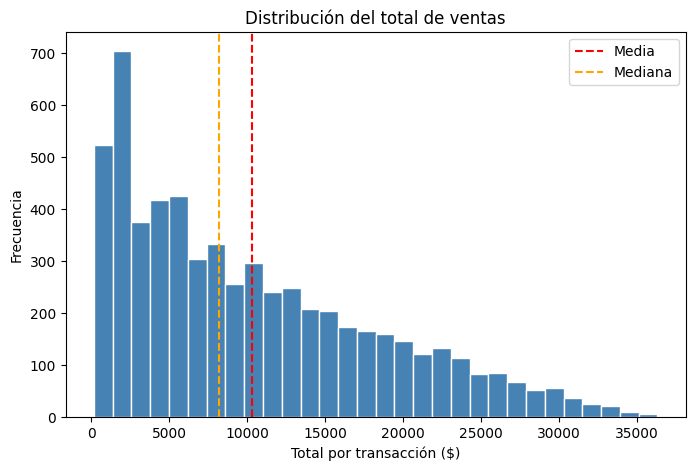

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(ventas["total"], bins=30, color="steelblue", edgecolor="white")
plt.axvline(ventas["total"].mean(), color="red", linestyle="--", label="Media")
plt.axvline(ventas["total"].median(), color="orange", linestyle="--", label="Mediana")
plt.title("Distribución del total de ventas")
plt.xlabel("Total por transacción ($)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

**a) ¿La distribución parece simétrica?** No. Tiene sesgo a la derecha: la mayor parte de las transacciones se concentra en montos bajos y medios, y hay una cola que se extiende hacia montos altos. La media (línea roja) queda a la derecha de la mediana (línea naranja), que es la huella típica de una distribución asimétrica positiva.

**b) ¿Se observan transacciones considerablemente mayores que el resto?** Sí, en el extremo derecho se ven barras pequeñas con transacciones de $30 mil o más. Son pocas, y coinciden con las 16 detectadas por el método IQR (arriba de ~$34 mil).

### Gráfica B: ventas por categoría

categoria
Deportes       25661252.05
Ropa           18547804.74
Electrónica     8818502.58
Hogar           4962168.70
Alimentos       3994336.51
Name: total, dtype: float64


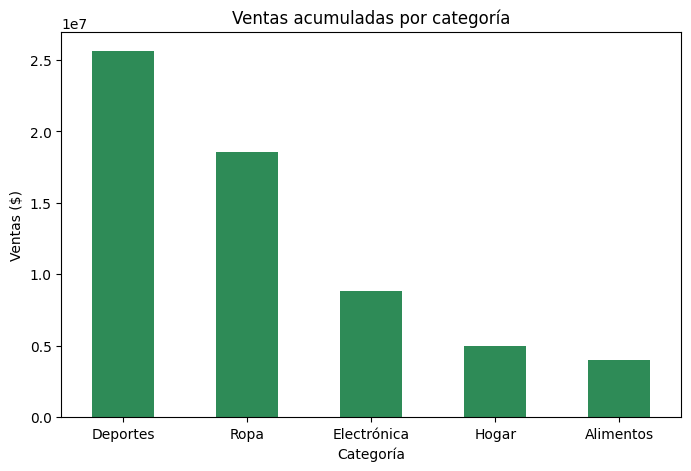

In [12]:
ventas_categoria = (
    ventas.groupby("categoria")["total"]
    .sum()
    .sort_values(ascending=False)
)
print(ventas_categoria.round(2))

ventas_categoria.plot(kind="bar", figsize=(8, 5), color="seagreen")
plt.title("Ventas acumuladas por categoría")
plt.ylabel("Ventas ($)")
plt.xlabel("Categoría")
plt.xticks(rotation=0)
plt.show()

In [13]:
# Ojo: no todas las categorías tienen el mismo número de productos
resumen_cat = ventas.groupby("categoria").agg(
    productos=("nombre_producto", "nunique"),
    transacciones=("total", "count"),
    ticket_promedio=("total", "mean"),
    monto=("total", "sum"),
)
resumen_cat["% del total"] = (resumen_cat["monto"] / resumen_cat["monto"].sum() * 100).round(1)
resumen_cat.sort_values("monto", ascending=False).round(2)

,productos,transacciones,ticket_promedio,monto,% del total
categoria,,,,,
Deportes,7,2118,12115.79,25661252.05,41.4
Ropa,5,1555,11927.85,18547804.74,29.9
Electrónica,4,1160,7602.16,8818502.58,14.2
Hogar,1,317,15653.53,4962168.70,8.0
Alimentos,3,850,4699.22,3994336.51,6.4


**¿Qué categoría genera el mayor monto acumulado?** **Deportes**, con ~$25.7 millones (41% de las ventas), seguida de Ropa con ~$18.5 millones (30%). Entre las dos concentran el 71% del monto.

Un matiz importante que salió de la tabla de apoyo: Deportes tiene 7 productos distintos y Ropa 5, mientras que Hogar tiene uno solo. Por eso, parte de que Deportes gane es simplemente que tiene más productos en catálogo. Hogar, con un solo producto, tiene el ticket promedio más alto ($15,654 por transacción) pero pocas transacciones (317), así que suma menos.

## Parte 5. Merge y análisis regional

In [14]:
regiones = pd.read_csv("regiones.csv")
regiones

,region_id,region,pais
0,1,Norte,México
1,2,Sur,México
2,3,Centro,México
3,4,Bajío,México
4,5,Sureste,México


In [15]:
ventas_completas = ventas.merge(regiones, on="region_id", how="inner")

# Antes de seguir, reviso que el merge no haya perdido ni duplicado filas
print("Filas en ventas:", len(ventas))
print("Filas después del merge:", len(ventas_completas))
ventas_completas.head()

Filas en ventas: 6000
Filas después del merge: 6000


,fecha,region_id,vendedor,producto_id,cantidad,nombre_producto,categoria,precio_unitario,total,region,pais
0,2023-01-01,1,Vendedor_4,7,9,Producto 7,Electrónica,1932.73,17394.57,Norte,México
1,2023-01-01,3,Vendedor_10,5,5,Producto 5,Ropa,1240.04,6200.20,Centro,México
2,2023-01-01,5,Vendedor_6,1,1,Producto 1,Electrónica,1264.57,1264.57,Sureste,México
3,2023-01-01,4,Vendedor_9,14,3,Producto 14,Deportes,2949.45,8848.35,Bajío,México
4,2023-01-01,2,Vendedor_6,17,4,Producto 17,Ropa,1593.14,6372.56,Sur,México


In [16]:
ventas_region = (
    ventas_completas
    .groupby("region")["total"]
    .sum()
    .sort_values(ascending=False)
)

print(ventas_region.round(2))

region
Sur        12850555.26
Centro     12737707.39
Norte      12272701.72
Sureste    12096084.01
Bajío      12027016.20
Name: total, dtype: float64


In [17]:
# ¿Cambiaría algo con un left join? (lo compruebo en vez de suponerlo)
left = ventas.merge(regiones, on="region_id", how="left")
print("Filas con left join:", len(left), "| filas sin región asignada:", left["region"].isna().sum())

Filas con left join: 6000 | filas sin región asignada: 0


**Región con mayores ventas:** **Sur** (~$12.85 millones), seguida de cerca por Centro (~$12.74 M). La región más baja es Bajío (~$12.03 M). Entre la primera y la última hay solo ~7% de diferencia, así que las cinco regiones están bastante parejas y la ventaja del Sur es pequeña.

**¿Por qué fue necesario el merge?** Porque `ventas.csv` solo trae `region_id` (un número) y el nombre de la región vive en otra tabla, `regiones.csv`. Sin la unión, el reporte diría "región 2" en lugar de "Sur". Además, el merge separa la información por tablas (ventas por un lado, catálogo de regiones por otro) sin repetir el nombre miles de veces. Verifiqué que el merge no perdió ni duplicó filas (6,000 antes y 6,000 después).

**Diferencia entre inner join y left join:** el `inner` se queda solo con las filas cuya clave existe en **ambas** tablas; el `left` conserva **todas** las filas de la tabla izquierda (`ventas`) y, si no encuentra región, deja NaN. En este caso los dos dan lo mismo (6,000 filas, 0 sin región) porque todos los `region_id` de ventas existen en el catálogo. Habría diferencia si hubiera ventas con un `region_id` que no aparece en `regiones.csv`: el inner las eliminaría en silencio y el left las dejaría visibles con región vacía, que es preferible para detectar errores.

## Reto final

*Escritas como se las diría a alguien que no conoce Python:*

1. **Sobre ventas:** En los tres años analizados (2023–2025) la empresa vendió alrededor de **$62 millones** en 6,000 transacciones, con un ticket promedio de ~$10,300. Casi todas las ventas son de tamaño "normal"; solo unas 16 (0.3%) son excepcionalmente grandes y son ventas reales de productos caros en la cantidad máxima, no errores.

2. **Sobre productos o categorías:** **Deportes** es la categoría que más dinero deja (41% del total) y **Producto 13** es el producto individual que más vende en pesos. Ojo: Deportes también es la categoría con más productos, así que su liderazgo es en parte efecto del tamaño del catálogo.

3. **Sobre regiones y comportamiento de los datos:** Las cinco regiones venden cantidades muy parecidas (entre $12.0 y $12.9 millones); el **Sur** va primero pero solo por ~7% sobre la última, así que no hay una región claramente "débil" o "fuerte". Los datos están completos (sin nulos ni duplicados) y el merge con el catálogo de regiones no perdió información.

## Pregunta de reflexión

Resultado hipotético: *Producto 13 es el producto con mayores ventas.* ¿Podemos concluir que es el que más unidades vendió?

In [18]:
# Lo reviso con los datos reales: ranking por monto vs ranking por unidades
resumen = ventas.groupby("nombre_producto").agg(
    monto_total=("total", "sum"),
    unidades=("cantidad", "sum"),
    precio_promedio=("precio_unitario", "mean"),
).round(2)

resumen["rank_monto"] = resumen["monto_total"].rank(ascending=False).astype(int)
resumen["rank_unidades"] = resumen["unidades"].rank(ascending=False).astype(int)
resumen.sort_values("rank_monto").head(8)

,monto_total,unidades,precio_promedio,rank_monto,rank_unidades
nombre_producto,,,,,
Producto 13,5657119.42,1896,2985.80,1,7
Producto 14,5234997.57,1895,2760.15,2,8
Producto 4,5115906.98,2016,2533.99,3,1
Producto 9,4962168.70,1929,2571.81,4,4
Producto 15,4654430.73,1940,2393.67,5,3
Producto 2,4621816.82,1618,2856.57,6,19
Producto 11,4289500.77,1837,2338.54,7,11
Producto 3,3827565.39,1909,2003.37,8,6


In [19]:
print("Producto con más monto:   ", resumen["monto_total"].idxmax())
print("Producto con más unidades:", resumen["unidades"].idxmax())

Producto con más monto:    Producto 13
Producto con más unidades: Producto 4


**Respuesta: No.**

El monto total vendido es `cantidad × precio`, entonces un producto puede liderar en pesos por tener un **precio alto** aunque venda **pocas unidades**, o al revés. Que Producto 13 tenga el mayor monto no implica que sea el que más unidades vendió.

Y aquí no fue solo teoría: en los datos, Producto 13 es el #1 en monto ($5.66 M) pero solo el #7 en unidades (1,896), mientras que **Producto 4** es el #1 en unidades (2,016) y apenas el #3 en monto. Otro caso más marcado es Producto 2, que es #6 en monto pero #19 en unidades: vende poco, pero muy caro. Por eso, antes de decir "el producto que más vende", hay que aclarar si se habla de dinero o de unidades, porque responden preguntas de negocio distintas (ingresos vs. volumen/logística).